# PRODUCT ANALYSIS

## BUSINESS CASE

1. Kategori produk mana yang memiliki rata-rata harga tertinggi?
2. Apakah ada korelasi antara berat/dimensi produk dengan freight value?
3. Produk dengan harga lebih tinggi apakah memiliki freight value yang lebih tinggi?


## IMPORT LIBRARY

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

## GATHERING DATA

In [2]:
order_items = pd.read_csv('https://raw.githubusercontent.com/adinfir/data-new/refs/heads/main/E-commerce-public-dataset/order_items_dataset.csv')
name_translate_product = pd.read_csv('https://raw.githubusercontent.com/adinfir/data-new/refs/heads/main/E-commerce-public-dataset/product_category_name_translation.csv')
product = pd.read_csv('https://raw.githubusercontent.com/adinfir/data-new/refs/heads/main/E-commerce-public-dataset/products_dataset.csv')

## DATA UNDERSTANDING

In [3]:
order_items.head(5)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [4]:
product.head(5)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


### GRAIN

1. tabel order_items : 1 row mempresentasikan item dalam sebuah order
2. tabel products : 1 row mempresentasikan 1 product

### KEY COLUMN

1. **Tabel `order_items`**:
   - `order_id` → identifier order
   - `order_item_id` → identifier order item id
   - `product_id` → identifier product, digunakan untuk menghubungkan `order_items` dengan `products`
   - `price` → harga item
   - `freight_value` → nilai freight/pengiriman

2. **Tabel `products`**:
   - `product_id` → identifier untuk setiap product
   - `product_category_name` → kategori product
   - `product_weight_g` → berat product

### RELATIONSHIP TABLE

- Tabel `order_items` dan `products` terhubung melalui `product_id`.

- `products` memiliki hubungan **one-to-many (1:N)** dengan `order_items`, karena satu product dapat muncul pada beberapa order item.

## DATA QUALITY

### ASESSING DATA

In [5]:
order_items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [6]:
order_items.describe(include='all')

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
count,112650,112650.000000,112650,112650,112650,112650.000000,112650.000000
unique,98666,NaN,32951,3095,93318,NaN,NaN
top,8272b63d03f5f79c56e9e4120aec44ef,NaN,aca2eb7d00ea1a7b8ebd4e68314663af,6560211a19b47992c3666cc44a7e94c0,2017-07-21 18:25:23,NaN,NaN
freq,21,NaN,527,2033,21,NaN,NaN
mean,NaN,1.197834,NaN,NaN,NaN,120.653739,19.990320
std,NaN,0.705124,NaN,NaN,NaN,183.633928,15.806405
min,NaN,1.000000,NaN,NaN,NaN,0.850000,0.000000
25%,NaN,1.000000,NaN,NaN,NaN,39.900000,13.080000
50%,NaN,1.000000,NaN,NaN,NaN,74.990000,16.260000
75%,NaN,1.000000,NaN,NaN,NaN,134.900000,21.150000


In [7]:
print('Checking null value')
order_items.isna().sum()

Checking null value


order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [8]:
print('Checking duplicated value')
order_items.duplicated().sum()

Checking duplicated value


0

In [9]:
product.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [10]:
product.describe(include='all')

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32951,32341,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
unique,32951,73,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,1e9e8ef04dbcff4541ed26657ea517e5,cama_mesa_banho,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,3029,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,NaN,NaN,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,NaN,NaN,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,NaN,NaN,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,NaN,NaN,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,NaN,NaN,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000


In [11]:
print('Checking null value')
product.isna().sum()

Checking null value


product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

1.  Untuk kolom ```product_category_name```,```product_name_lenght```,```product_description_lenght```,``` product_photos_qty```,```product_weight_g```,```product_length_cm```,```product_height_cm```,```product_width_cm'``` terdapat missing value

In [12]:
print('Checking duplicated value')
product.duplicated().sum()

Checking duplicated value


0

### CLEANING DATA

#### MENGUBAH DI TABEL PRODUCT NAMA PRODUCT YANG NULL MENJADI UNKOWN + 5 HURUF TERAKHIR PRODUCT ID 

In [13]:
product['product_category_name'] = product['product_category_name'].fillna(
    'unkown_' + product['product_id'].str[-5:])

**DATA QUALITY NOTE**

Pada kolom `product_category_name` ditemukan nilai null. Karena produk dengan kategori yang tidak tersedia tetap memiliki `product_id` dan masih relevan untuk analisis, data tersebut tidak dikeluarkan. Nilai null kemudian ditangani dengan membuat label **`unkown_` + 5 karakter terakhir dari `product_id`** sebagai identifikasi kategori yang tidak diketahui.


#### MENGISI KOLOM NAME LENGTH, DESCRIPTION LENGHT, DAN PHOTOS QTY DENGAN 0

In [14]:
product['product_name_lenght'] = product['product_name_lenght'].fillna(0)
product['product_description_lenght'] = product['product_description_lenght'].fillna(0)
product['product_photos_qty'] = product['product_photos_qty'].fillna(0)

In [15]:
print('Jumlah missing value setelah dilakukan penanganan')
product.isna().sum()

Jumlah missing value setelah dilakukan penanganan


product_id                    0
product_category_name         0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              2
product_length_cm             2
product_height_cm             2
product_width_cm              2
dtype: int64

**DATA QUALITY NOTE**

Pada pemeriksaan data ditemukan **2 missing value pada `product_weight_g`**. Karena variabel tersebut digunakan dalam analisis EDA Q2 untuk melihat hubungan antara berat produk dan `freight_value`, treatment terhadap missing value akan dilakukan pada saat proses pengerjaan **EDA Q2** agar penanganan data disesuaikan dengan kebutuhan analisis.


#### TRANSLATE PRODUCT CATEGORY NAME

In [16]:
translate = name_translate_product.set_index('product_category_name')['product_category_name_english']
product['product_category_name'] = product['product_category_name'].map(translate).fillna(product['product_category_name'])

## DATA PREPARATION

### MEMILIH FEATURE YANG DIGUNAKAN UNTUK ANALYSIS

In [17]:
order_items = order_items[['order_id','order_item_id','product_id', 'price','freight_value']]
product = product[['product_id','product_category_name','product_weight_g']]

### JOIN TABEL

In [18]:
order_items_product = pd.merge(
    left = order_items,
    right = product,
    how = 'left',
    on= 'product_id'
)
order_items_product.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               112650 non-null  object 
 1   order_item_id          112650 non-null  int64  
 2   product_id             112650 non-null  object 
 3   price                  112650 non-null  float64
 4   freight_value          112650 non-null  float64
 5   product_category_name  112650 non-null  object 
 6   product_weight_g       112632 non-null  float64
dtypes: float64(3), int64(1), object(3)
memory usage: 6.0+ MB


In [19]:
order_items_product.duplicated().sum()

0

## EXPLORATORY DATA ANALYSIS

### 1. Kategori produk mana yang memiliki rata-rata harga tertinggi?

In [20]:
avg_price = order_items_product[['product_category_name','order_item_id','price']]

In [21]:
highest_avg_price = avg_price.groupby('product_category_name').agg({
    'price' : 'mean',
    'order_item_id' : 'count'
}).reset_index()

In [22]:
highest_avg_price.sort_values(by='price', ascending=False).head(30)

,product_category_name,price,order_item_id
181,unkown_2c4a9,3980.000000,1
152,unkown_1fd5e,2740.000000,1
355,unkown_7507d,1989.000000,5
676,unkown_fd644,1699.000000,1
497,unkown_b3d29,1599.000000,1
648,unkown_f2f33,1260.000000,1
523,unkown_bef07,1159.000000,1
14,computers,1098.340542,203
509,unkown_b9f70,999.900000,2
365,unkown_7c834,990.000000,1


**DATA QUALITY NOTE**

Pada kolom `product_category_name` terdapat nilai null yang ditangani dengan label `unkown_` + 5 karakter terakhir dari `product_id` agar produk tetap dapat dipertahankan dalam dataset. Namun, pada EDA Q1, kategori `unkown_*` tidak digunakan dalam perbandingan rata-rata harga antar-kategori karena label tersebut bukan merupakan kategori produk sebenarnya. Treatment ini dilakukan khusus untuk kebutuhan analisis Q1 dan tidak menghapus data `unkown_*` dari dataset utama maupun analisis EDA lainnya.


In [23]:
highest_avg_price = highest_avg_price[~highest_avg_price['product_category_name'].str.contains('unkown', na=False)]

In [24]:
highest_avg_price.sort_values(by='price', ascending=False).head(10)

,product_category_name,price,order_item_id
14,computers,1098.340542,203
66,small_appliances_home_oven_and_coffee,624.285658,76
45,home_appliances_2,476.124958,238
0,agro_industry_and_commerce,342.124858,212
56,musical_instruments,281.616000,680
65,small_appliances,280.778468,679
62,portateis_cozinha_e_preparadores_de_alimentos,264.568667,15
34,fixed_telephony,225.693182,264
19,construction_tools_safety,208.992371,194
682,watches_gifts,201.135984,5991


C:\Users\adien\AppData\Local\Temp\ipykernel_20336\3680653100.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


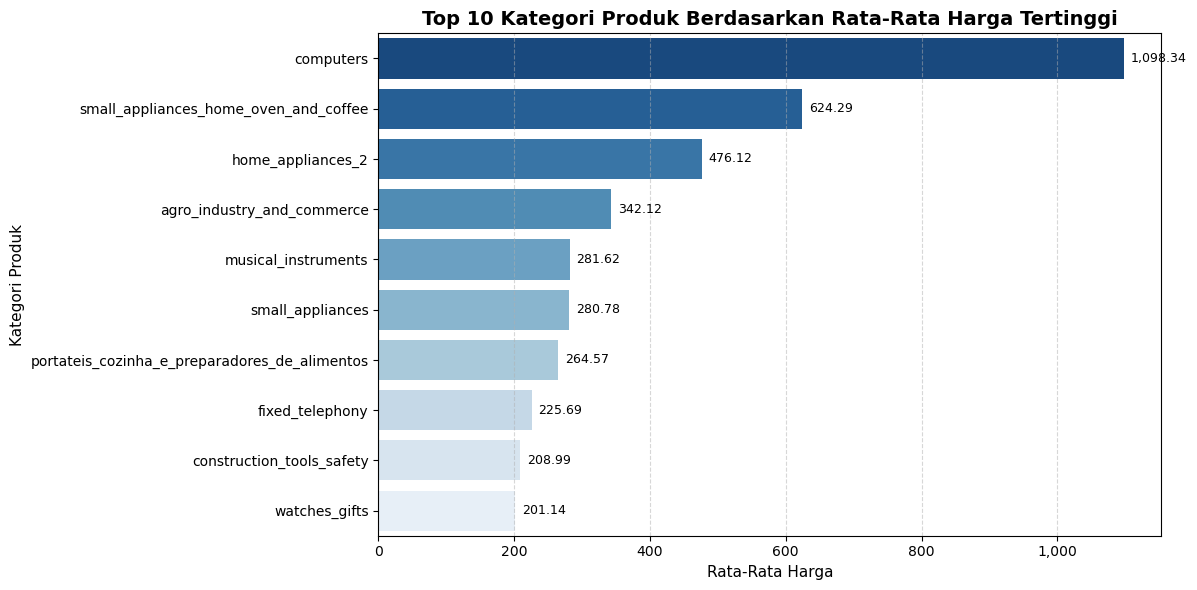

In [25]:
# 1. Ambil 10 data teratas (diurutkan dari terbesar)
# Sesuaikan 'Total Revenue' dan 'product_category_name' dengan nama kolom Anda
top_10 = highest_avg_price.sort_values(by='price', ascending=False).head(10)

# 2. Buat kanvas plot
plt.figure(figsize=(12, 6))

# 3. Membuat Horizontal Bar Plot
# (y = Nama Kategori, x = Nilai Angka)
ax = sns.barplot(
    data=top_10,
    x='price',            # Sumbu X (Angka)
    y='product_category_name',   # Sumbu Y (Kategori)
    palette='Blues_r'            # Gradasi warna biru dari gelap ke terang (opsional)
)

# 4. Menambahkan Label Angka di Ujung Setiap Batang
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='{:,.2f}',               # Format koma pemisah ribuan
        padding=5,                   # Jarak teks dari batang
        fontsize=9
    )

# 5. Mengatasi format 1e6 pada sumbu X
ax.xaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

# 6. Judul dan Label Sumbu
plt.title('Top 10 Kategori Produk Berdasarkan Rata-Rata Harga Tertinggi', fontsize=14, fontweight='bold')
plt.xlabel('Rata-Rata Harga', fontsize=11)
plt.ylabel('Kategori Produk', fontsize=11)

# Garis grid horizontal dibuang, cukup beri garis grid vertical di sumbu X
plt.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout() # Agar layout tidak terpotong saat disimpan/ditampilkan
plt.show()

**CATATAN**

kategori unkown_* tidak digunakan dalam perbandingan rata-rata harga antar-kategori karena label tersebut bukan merupakan kategori produk sebenarnya."

#### KEY INSIGHT

1. **Kategori `computers` memiliki rata-rata harga tertinggi**, yaitu sebesar **R$1.098,34** dengan total **203 order item**.

2. **Kategori `small_appliances_home_oven_and_coffee` memiliki rata-rata harga tertinggi kedua**, yaitu sebesar **R$624,29** dengan total **76 order item**.


### 2. Apakah ada korelasi antara berat/dimensi produk dengan freight value?

In [26]:
weight_freight = order_items_product[['order_id','order_item_id','product_category_name','freight_value','product_weight_g']]

In [27]:
weight_freight.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 5 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               112650 non-null  object 
 1   order_item_id          112650 non-null  int64  
 2   product_category_name  112650 non-null  object 
 3   freight_value          112650 non-null  float64
 4   product_weight_g       112632 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 4.3+ MB


**DATA QUALITY NOTE**

Terdapat **18 missing value** pada kolom `product_weight_g`. Karena informasi yang tersedia tidak mencukupi untuk melakukan validasi dan menentukan nilai imputasi yang sesuai, data dengan nilai `product_weight_g` yang null akan **dikeluarkan dari analisis**.


In [28]:
weight_freight= weight_freight.dropna()

In [29]:
weight_freight.info()

<class 'pandas.core.frame.DataFrame'>
Index: 112632 entries, 0 to 112649
Data columns (total 5 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               112632 non-null  object 
 1   order_item_id          112632 non-null  int64  
 2   product_category_name  112632 non-null  object 
 3   freight_value          112632 non-null  float64
 4   product_weight_g       112632 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 5.2+ MB


In [30]:
weight_freight.duplicated().sum()

0

In [31]:
corr_weight_freight = order_items_product[['freight_value','product_weight_g']]

In [32]:
corr_weight_freight.corr()

,freight_value,product_weight_g
freight_value,1.00000,0.61042
product_weight_g,0.61042,1.00000


In [33]:
scatter_weight_freight = order_items_product[['product_category_name','freight_value','product_weight_g']]

In [34]:
## MELAKUKAN CHECK DUPLICATE
scatter_weight_freight.duplicated().sum()

49906

In [35]:
## MELAKUKAN DROP DUPLICATE
scatter_weight_freight.drop_duplicates(inplace=True)

C:\Users\adien\AppData\Local\Temp\ipykernel_20336\642780274.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  scatter_weight_freight.drop_duplicates(inplace=True)


**DATA QUALITY NOTE**

Pada dataset yang digunakan untuk visualisasi scatter plot terdapat **49.906 data** dengan variabel `price`, `freight_value`, dan `product_name`. Ditemukan data dengan kombinasi nilai yang sama pada ketiga kolom tersebut, sehingga dilakukan **deduplikasi** untuk menghindari penampilan titik yang sama secara berulang pada scatter plot. Proses deduplikasi ini dilakukan khusus untuk kebutuhan visualisasi dan tidak memengaruhi data utama yang digunakan dalam analisis.


In [36]:
## MELAKUKAN CHECK DUPLICATE
scatter_weight_freight.duplicated().sum()

0

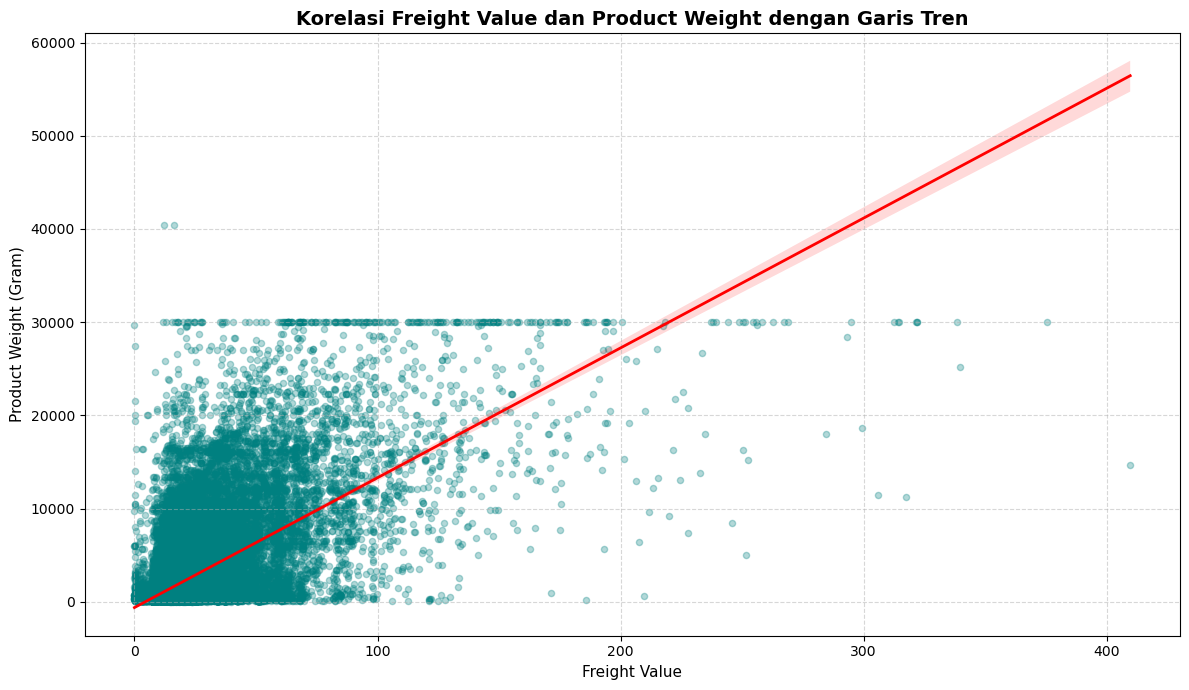

In [37]:
plt.figure(figsize=(12, 7))

# Menggunakan regplot untuk menampilkan scatter sekaligus garis tren
sns.regplot(
    data=scatter_weight_freight,
    x='freight_value', 
    y='product_weight_g',
    scatter_kws={'alpha': 0.3, 's': 20, 'color': 'teal'}, # Pengaturan untuk titik (scatter)
    line_kws={'color': 'red', 'linewidth': 2}             # Pengaturan untuk garis tren
)

plt.title('Korelasi Freight Value dan Product Weight dengan Garis Tren', fontsize=14, fontweight='bold')
plt.xlabel('Freight Value', fontsize=11)
plt.ylabel('Product Weight (Gram)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#### KEY INSIGHT

Setelah dilakukan analisis korelasi antara `product_weight` dan `freight_value`, diperoleh nilai korelasi sebesar **0,61042**. Nilai tersebut menunjukkan adanya **korelasi positif dengan tingkat kekuatan tinggi** berdasarkan pembagian lima tingkat interpretasi korelasi yang digunakan.berat product_weight yang tinggi cenderung memiliki freight value yang tinggi

### 3. Produk dengan harga lebih tinggi apakah memiliki freight value yang lebih tinggi?

In [38]:
price_freight = order_items_product[['product_category_name','price','freight_value']]

In [39]:
price_freight_avg = price_freight.groupby('product_category_name').agg({
    'price' : 'mean',
    'freight_value' : 'mean'
}).reset_index()

In [40]:
corr_price_freight_avg = price_freight_avg[['price','freight_value']]
corr_price_freight_avg.corr()

,price,freight_value
price,1.000000,0.449179
freight_value,0.449179,1.000000


In [41]:
scatter_price_freight = price_freight_avg

In [42]:
##CHECK DUPLICATE DATA
scatter_price_freight.duplicated().sum()

0

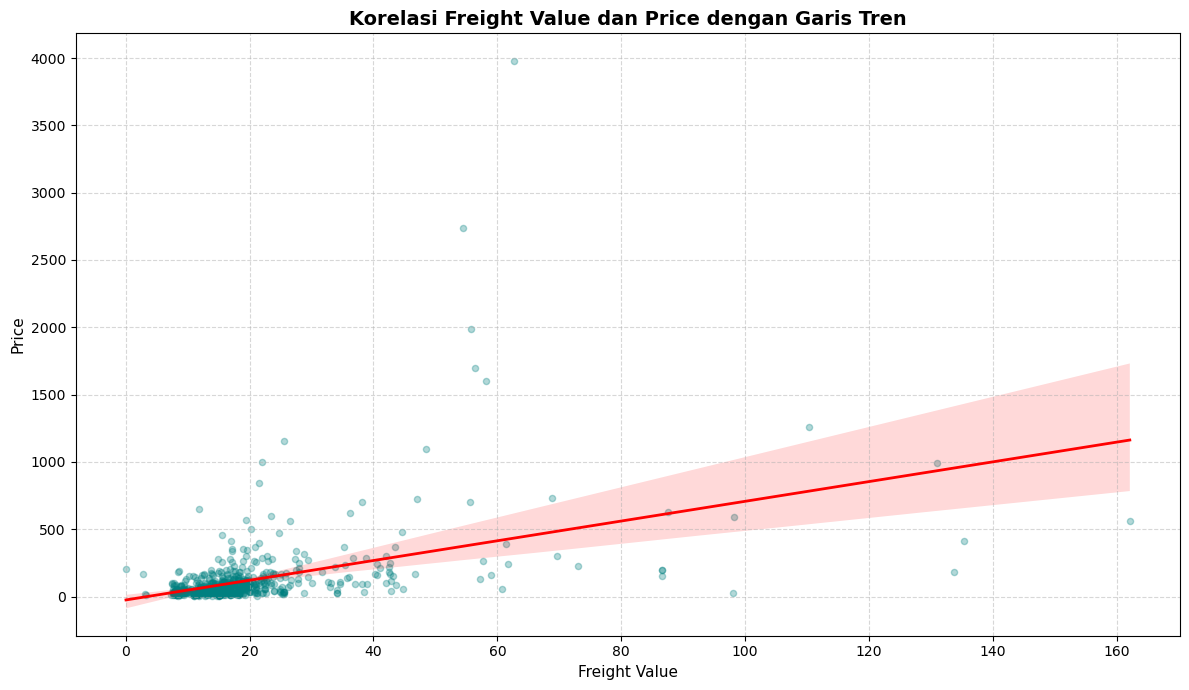

In [43]:
plt.figure(figsize=(12, 7))

# Menggunakan regplot untuk menampilkan scatter sekaligus garis tren
sns.regplot(
    data=scatter_price_freight,
    x='freight_value', 
    y='price',
    scatter_kws={'alpha': 0.3, 's': 20, 'color': 'teal'}, # Pengaturan untuk titik (scatter)
    line_kws={'color': 'red', 'linewidth': 2}             # Pengaturan untuk garis tren
)

plt.title('Korelasi Freight Value dan Price dengan Garis Tren', fontsize=14, fontweight='bold')
plt.xlabel('Freight Value', fontsize=11)
plt.ylabel('Price', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

#### KEY INSIGHT

1. Terdapat **korelasi positif sebesar 0,449179** antara `price` dan `freight_value`, yang menunjukkan hubungan dengan **tingkat kekuatan cukup** berdasarkan interpretasi korelasi yang digunakan.

2. Hasil analisis menunjukkan bahwa **produk dengan harga lebih tinggi cenderung memiliki `freight_value` yang lebih tinggi**.


## KEY FINDINGS

1. **Kategori `computers` memiliki rata-rata harga tertinggi**, yaitu sebesar **R$1.098,34** dengan total **203 order item**.

2. **Kategori `small_appliances_home_oven_and_coffee` memiliki rata-rata harga tertinggi kedua**, yaitu sebesar **R$624,29** dengan total **76 order item**.

3. Setelah dilakukan analisis korelasi antara `product_weight` dan `freight_value`, diperoleh nilai korelasi sebesar **0,61042**. Nilai tersebut menunjukkan adanya **korelasi positif dengan tingkat kekuatan tinggi** berdasarkan pembagian lima tingkat interpretasi korelasi yang digunakan.berat product_weight yang tinggi cenderung memiliki freight value yang tinggi

4. Terdapat **korelasi positif sebesar 0,449179** antara `price` dan `freight_value`, yang menunjukkan hubungan dengan **tingkat kekuatan cukup** berdasarkan interpretasi korelasi yang digunakan.**produk dengan harga lebih tinggi cenderung memiliki `freight_value` yang lebih tinggi**.



## BUSINESS IMPLICATIONS

1. **Memprioritaskan pengelolaan kategori dengan harga tinggi**
   Kategori dengan rata-rata harga yang lebih tinggi, khususnya `computers`, dapat menjadi perhatian dalam pengelolaan produk dan strategi penjualan karena memiliki nilai transaksi produk yang relatif tinggi.

2. **Mempertimbangkan berat produk dalam pengelolaan biaya pengiriman**
   Hubungan positif antara `product_weight` dan `freight_value` menunjukkan bahwa karakteristik fisik produk perlu diperhatikan dalam perencanaan dan evaluasi biaya pengiriman, terutama untuk produk dengan berat yang lebih tinggi.

3. **Mempertimbangkan harga produk dalam evaluasi biaya pengiriman**
   Produk dengan harga lebih tinggi cenderung memiliki `freight_value` yang lebih tinggi. Informasi ini dapat digunakan sebagai salah satu pertimbangan dalam mengevaluasi struktur biaya pengiriman berdasarkan karakteristik produk.

4. **Menggunakan analisis produk sebagai dasar evaluasi pricing dan logistics**
   Hubungan antara harga, berat produk, dan `freight_value` dapat digunakan secara bersama-sama untuk memahami faktor yang berkaitan dengan biaya pengiriman dan mendukung evaluasi strategi produk serta logistik.
